In [4]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

In [5]:
# Load dataset
df = pd.read_csv("student-mat.csv", sep=';')

# Target
df['pass'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

# 🚨 REMOVE ALL GRADE FEATURES (IMPORTANT FIX)
df = df.drop(['G1', 'G2', 'G3'], axis=1)

In [6]:
# Encode categorical columns
le_dict = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        le_dict[col] = le  # store encoders (important for Streamlit)

In [7]:
# Features / target
X = df.drop('pass', axis=1)
y = df['pass']

# Split (IMPORTANT: shuffle=True by default)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [9]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name}")
    print("Accuracy:", acc)

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)


Logistic Regression
Accuracy: 0.759493670886076
Confusion Matrix:
 [[12 15]
 [ 4 48]]

Decision Tree
Accuracy: 0.7088607594936709
Confusion Matrix:
 [[13 14]
 [ 9 43]]

Gradient Boosting
Accuracy: 0.6962025316455697
Confusion Matrix:
 [[ 9 18]
 [ 6 46]]


In [10]:
# Best model
best_model_name = max(results, key=results.get)
print("\nBest Model:", best_model_name)


Best Model: Logistic Regression


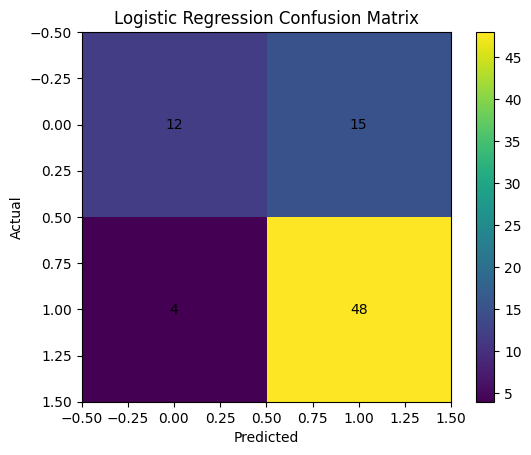

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Train ONLY Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict using Logistic Regression
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.imshow(cm)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

In [12]:
import pickle

In [14]:
best_model = models[best_model_name]

In [15]:
with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)